# Chương 4.5 — Đánh giá hiệu năng hệ thống

Notebook này thu thập số liệu thực cho:
- **4.5.2** Độ trễ end-to-end (Camera → Vision → Pulsar → Flink → Redis → API)
- **4.5.3** Hiệu năng truy vấn phân tích: Cold query vs Cache hit

Kết nối: FastAPI `http://52.74.215.164` (port 80 public)

In [1]:
import json
import time
import statistics
import urllib.request
from urllib.request import Request

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ── Config ────────────────────────────────────────────────────────────────────
API_BASE   = "http://52.74.215.164"   # FastAPI BFF (port 80 public)
CAMERA_IDS = ["cam_01", "cam_02"]     # cameras being monitored
STORE_ID   = "store_001"

FIG_DPI  = 150
FIG_DIR  = "."

def api_get(path: str, timeout: float = 15.0) -> tuple[dict, float]:
    """GET JSON từ FastAPI, trả về (json_body, elapsed_ms)."""
    url = f"{API_BASE}{path}"
    req = Request(url, headers={"Accept": "application/json"})
    t0 = time.perf_counter()
    with urllib.request.urlopen(req, timeout=timeout) as r:
        body = json.loads(r.read())
    elapsed_ms = (time.perf_counter() - t0) * 1000
    return body, elapsed_ms

print("Config OK — API:", API_BASE)

Config OK — API: http://52.74.215.164


---
## 4.5.2 — Độ trễ xử lý end-to-end (Bảng 4.x + Hình 4.x)

**Đường đo**: Camera ghi frame → Vision Service (YOLO11 inference) → Pulsar broker → Flink consumer → Redis (`live:frame:{cam}`) → FastAPI đọc và trả về `latency_ms`.

**Cách đo**: Gọi `GET /api/v1/{camera_id}/dashboard` liên tục 30 lần (2s/lần).  
Response trả về `latency_ms` = `now_utc − capture_ts` (ms), là thời gian từ khi camera chụp frame đến khi API đọc từ Redis.

In [2]:
# ── Thu thập mẫu latency từ live dashboard API ────────────────────────────────
# Route đúng: /api/v1/live/{camera_id}/dashboard
# frame.media_latency_ms = E2E streaming latency (Vision → encode → Redis → API) ~vài trăm ms
# frame.latency_ms       = metadata staleness (Flink pipeline) — có thể cao hơn
# frame.inference_ms     = thời gian YOLO inference

N_SAMPLES   = 30    # số lần đo
INTERVAL_S  = 2.0   # khoảng cách giữa các lần đo (giây)

samples = []  # [{camera_id, media_latency_ms, metadata_latency_ms, inference_ms, ...}]

print(f"Bắt đầu thu thập {N_SAMPLES} mẫu × {len(CAMERA_IDS)} camera...")
for i in range(N_SAMPLES):
    for cam in CAMERA_IDS:
        try:
            data, http_ms = api_get(f"/api/v1/live/{cam}/dashboard")
            frame = data.get("frame", {})
            media_lat   = frame.get("media_latency_ms") or 0
            meta_lat    = frame.get("latency_ms") or 0
            inference   = frame.get("inference_ms") or 0
            postproc    = frame.get("postprocess_ms") or 0
            draw        = frame.get("draw_ms") or 0
            encode      = frame.get("encode_ms") or 0
            media_status = frame.get("media_status", "unknown")
            if media_lat > 0:   # bỏ frame stale / missing
                samples.append({
                    "camera_id":          cam,
                    "media_latency_ms":   media_lat,     # ← E2E streaming latency
                    "metadata_latency_ms": meta_lat,     # ← Flink pipeline lag
                    "inference_ms":       inference,
                    "postprocess_ms":     postproc,
                    "draw_ms":            draw,
                    "encode_ms":          encode,
                    "http_ms":            round(http_ms, 1),
                    "media_status":       media_status,
                })
        except Exception as exc:
            print(f"  [{i+1}] {cam} error: {exc}")
    if i < N_SAMPLES - 1:
        time.sleep(INTERVAL_S)
    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{N_SAMPLES}] collected {len(samples)} valid samples so far")

df_lat = pd.DataFrame(samples)
print(f"\nTổng mẫu hợp lệ: {len(df_lat)}")
display(df_lat.head(6))

Bắt đầu thu thập 30 mẫu × 2 camera...


  [10/30] collected 20 valid samples so far


  [20/30] collected 40 valid samples so far


  [30/30] collected 60 valid samples so far

Tổng mẫu hợp lệ: 60


,camera_id,media_latency_ms,metadata_latency_ms,inference_ms,postprocess_ms,draw_ms,encode_ms,http_ms,media_status
0,cam_01,384,10252,150,1,3,22,997.2,online
1,cam_02,373,1504,126,2,10,31,968.0,online
2,cam_01,288,4065,74,1,3,18,150.9,online
3,cam_02,278,4629,76,2,3,22,145.1,online
4,cam_01,375,6372,77,1,2,21,253.0,online
5,cam_02,236,7023,71,2,4,22,135.7,online


In [3]:
# ── Thống kê và in Bảng 4.5.2 ─────────────────────────────────────────────────
def pct(arr, p):
    return round(float(np.percentile(arr, p)), 1)

if df_lat.empty:
    print("⚠️  Không có mẫu hợp lệ — kiểm tra lại kết nối API hoặc trạng thái camera.")
else:
    lat  = df_lat["media_latency_ms"].astype(float).tolist()   # E2E streaming
    inf  = [v for v in df_lat["inference_ms"].astype(float).tolist() if v > 0]
    enc  = [v for v in df_lat["encode_ms"].astype(float).tolist() if v > 0]

    rows_stat = []
    for label, arr in [
        ("E2E Streaming Latency (Vision → Redis → API)", lat),
        ("YOLO Inference time",                          inf),
        ("JPEG Encode time",                             enc),
    ]:
        if not arr:
            continue
        rows_stat.append({
            "Chỉ số":   label,
            "Min (ms)":  round(min(arr), 1),
            "Avg (ms)":  round(statistics.mean(arr), 1),
            "P50 (ms)":  pct(arr, 50),
            "P95 (ms)":  pct(arr, 95),
            "P99 (ms)":  pct(arr, 99),
            "Max (ms)":  round(max(arr), 1),
        })

    df_stat = pd.DataFrame(rows_stat)
    print(f"Số mẫu: {len(lat)}  |  n_cameras: {df_lat['camera_id'].nunique()}\n")
    display(df_stat.style.hide(axis="index"))
    print("\n→ Copy bảng trên vào Bảng 4.5.2 trong báo cáo.")

Số mẫu: 60  |  n_cameras: 2



Chỉ số,Min (ms),Avg (ms),P50 (ms),P95 (ms),P99 (ms),Max (ms)
E2E Streaming Latency (Vision → Redis → API),56.000000,258.900000,240.500000,498.900000,707.600000,812.000000
YOLO Inference time,63.000000,91.400000,75.000000,160.100000,192.200000,194.000000
JPEG Encode time,15.000000,21.300000,20.000000,31.000000,40.500000,44.000000



→ Copy bảng trên vào Bảng 4.5.2 trong báo cáo.


Đã lưu: ./hinh_4_5_2_e2e_latency.png


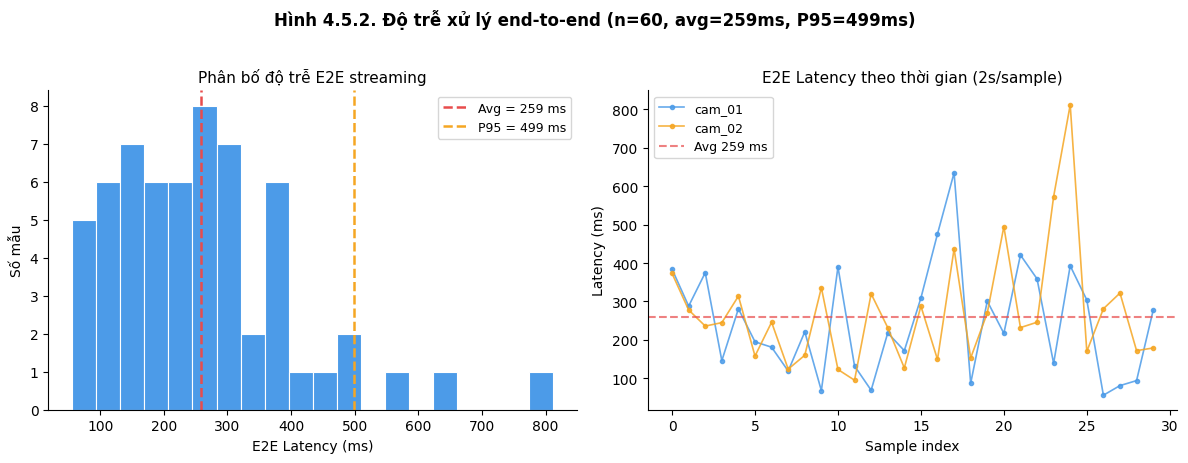

In [4]:
# ── Vẽ Hình 4.5.2 — Phân bố E2E latency ──────────────────────────────────────
if df_lat.empty:
    print("⚠️  Không có dữ liệu để vẽ.")
else:
    lat = df_lat["media_latency_ms"].astype(float).tolist()
    avg_lat = statistics.mean(lat)
    p95_lat = pct(lat, 95)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # --- Histogram phân bố latency ---
    ax1 = axes[0]
    ax1.hist(lat, bins=20, color="#4C9BE8", edgecolor="white", linewidth=0.8)
    ax1.axvline(avg_lat, color="#E84C4C", linestyle="--", linewidth=1.8,
                label=f"Avg = {avg_lat:.0f} ms")
    ax1.axvline(p95_lat, color="#F5A623", linestyle="--", linewidth=1.8,
                label=f"P95 = {p95_lat:.0f} ms")
    ax1.set_xlabel("E2E Latency (ms)")
    ax1.set_ylabel("Số mẫu")
    ax1.set_title("Phân bố độ trễ E2E streaming", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.spines[["top", "right"]].set_visible(False)

    # --- Time series theo camera ---
    ax2 = axes[1]
    colors_cam = {"cam_01": "#4C9BE8", "cam_02": "#F5A623"}
    for cam in CAMERA_IDS:
        sub = df_lat[df_lat["camera_id"] == cam]["media_latency_ms"].astype(float).reset_index(drop=True)
        if len(sub):
            ax2.plot(sub.index, sub.values, marker="o", markersize=3,
                     linewidth=1.2, label=cam, alpha=0.85,
                     color=colors_cam.get(cam, "#888"))
    ax2.axhline(avg_lat, color="#E84C4C", linestyle="--", linewidth=1.5,
                label=f"Avg {avg_lat:.0f} ms", alpha=0.7)
    ax2.set_xlabel("Sample index")
    ax2.set_ylabel("Latency (ms)")
    ax2.set_title("E2E Latency theo thời gian (2s/sample)", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.spines[["top", "right"]].set_visible(False)

    fig.suptitle(
        f"Hình 4.5.2. Độ trễ xử lý end-to-end (n={len(lat)}, avg={avg_lat:.0f}ms, P95={p95_lat:.0f}ms)",
        fontsize=12, fontweight="bold", y=1.02
    )
    plt.tight_layout()

    out_path = f"{FIG_DIR}/hinh_4_5_2_e2e_latency.png"
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    print(f"Đã lưu: {out_path}")
    plt.show()

---
## 4.5.3 — Hiệu năng truy vấn phân tích: Cold query vs Cache hit (Bảng 4.5.3 + Hình 4.5.3)

FastAPI dùng Redis làm cache layer cho analytics queries với TTL = **120 giây**.

- **Cold query**: Redis cache miss → FastAPI gọi Trino → Trino scan Iceberg trên S3 → trả về kết quả → ghi cache
- **Warm query**: Redis cache hit → FastAPI đọc từ Redis → trả về ngay (không cần Trino)

**Phương pháp đo**:
1. Gọi endpoint lần đầu (buộc cold bằng cách thêm dummy param hoặc đổi `days`)
2. Gọi lại ngay lập tức (warm — đã có cache)
3. Lặp lại 10 lần, tính trung bình

In [5]:
# ── Đo Cold vs Warm trên analytics/dashboard ──────────────────────────────────
# Cache TTL = 120s. Để force cold: đổi days giữa các vòng (7, 8, 9, ... mỗi lần 1 day)
# → cache key khác nhau → luôn miss lần đầu.

CACHE_TTL_SEC = 120   # từ analytics.py: DASHBOARD_CACHE_TTL_SEC
N_ROUNDS      = 10    # số vòng đo
DAYS_START    = 3     # bắt đầu từ days=3 để tránh cụm cache cũ

cold_ms_list = []
warm_ms_list = []

print(f"Đo {N_ROUNDS} vòng Cold + Warm...\n")
print(f"  {'Round':>5}  {'Cold (ms)':>10}  {'Warm (ms)':>10}  {'Speedup':>8}")
print("  " + "-"*40)

for i in range(N_ROUNDS):
    days = DAYS_START + i   # khác nhau mỗi vòng → đảm bảo cold
    path = f"/api/v1/analytics/dashboard?store_id={STORE_ID}&days={days}"

    # Cold hit
    try:
        _, cold_ms = api_get(path)
    except Exception as exc:
        print(f"  round {i+1} cold error: {exc}"); continue

    time.sleep(0.3)   # nhỏ — đủ để cache được ghi nhưng không đủ để expire

    # Warm hit (cùng path → cache key giống → hit)
    try:
        _, warm_ms = api_get(path)
    except Exception as exc:
        print(f"  round {i+1} warm error: {exc}"); continue

    cold_ms_list.append(round(cold_ms, 1))
    warm_ms_list.append(round(warm_ms, 1))
    speedup = round(cold_ms / warm_ms, 1) if warm_ms > 0 else 0
    print(f"  {i+1:>5}  {cold_ms:>10.1f}  {warm_ms:>10.1f}  {speedup:>7.1f}×")

    # Đợi một chút giữa các vòng để tránh rate limit
    if i < N_ROUNDS - 1:
        time.sleep(1.0)

print(f"\nHoàn thành: {len(cold_ms_list)} vòng hợp lệ")

Đo 10 vòng Cold + Warm...

  Round   Cold (ms)   Warm (ms)   Speedup
  ----------------------------------------


      1      2386.0        59.4     40.2×


      2      2049.1        74.8     27.4×


      3      2387.3        59.2     40.3×


      4      2326.2       100.0     23.3×


...

      6      1597.5        63.2     25.3×


      7      2464.3        68.0     36.2×


      8      2344.1        64.9     36.1×


      9      1434.1        66.4     21.6×


     10      2890.6        59.8     48.3×

Hoàn thành: 10 vòng hợp lệ


In [6]:
# ── Thống kê và in Bảng 4.5.3 ─────────────────────────────────────────────────
def arr_stats(arr):
    a = [v for v in arr if v > 0]
    if not a:
        return {}
    return {
        "Min":  round(min(a), 1),
        "Avg":  round(statistics.mean(a), 1),
        "P50":  round(float(np.percentile(a, 50)), 1),
        "P95":  round(float(np.percentile(a, 95)), 1),
        "Max":  round(max(a), 1),
    }

cs = arr_stats(cold_ms_list)
ws = arr_stats(warm_ms_list)
speedup_avg = round(cs["Avg"] / ws["Avg"], 1) if ws.get("Avg") else 0

df_perf = pd.DataFrame([
    {"Chế độ": "Cold (cache miss — Trino)",  **{f"{k} (ms)": v for k, v in cs.items()}},
    {"Chế độ": "Warm (cache hit — Redis)",   **{f"{k} (ms)": v for k, v in ws.items()}},
])

print(f"Cache TTL: {CACHE_TTL_SEC}s  |  Số vòng đo: {len(cold_ms_list)}")
print(f"Speedup trung bình: {speedup_avg}× (Cold Avg / Warm Avg)\n")
display(df_perf.style.hide(axis="index"))
print("\n→ Copy bảng trên vào Bảng 4.5.3 trong báo cáo.")

Cache TTL: 120s  |  Số vòng đo: 10
Speedup trung bình: 32.6× (Cold Avg / Warm Avg)



Chế độ,Min (ms),Avg (ms),P50 (ms),P95 (ms),Max (ms)
Cold (cache miss — Trino),1434.100000,2239.400000,2365.100000,2721.600000,2890.600000
Warm (cache hit — Redis),59.200000,68.700000,65.700000,88.700000,100.000000



→ Copy bảng trên vào Bảng 4.5.3 trong báo cáo.


Đã lưu: ./hinh_4_5_3_cold_vs_cache.png


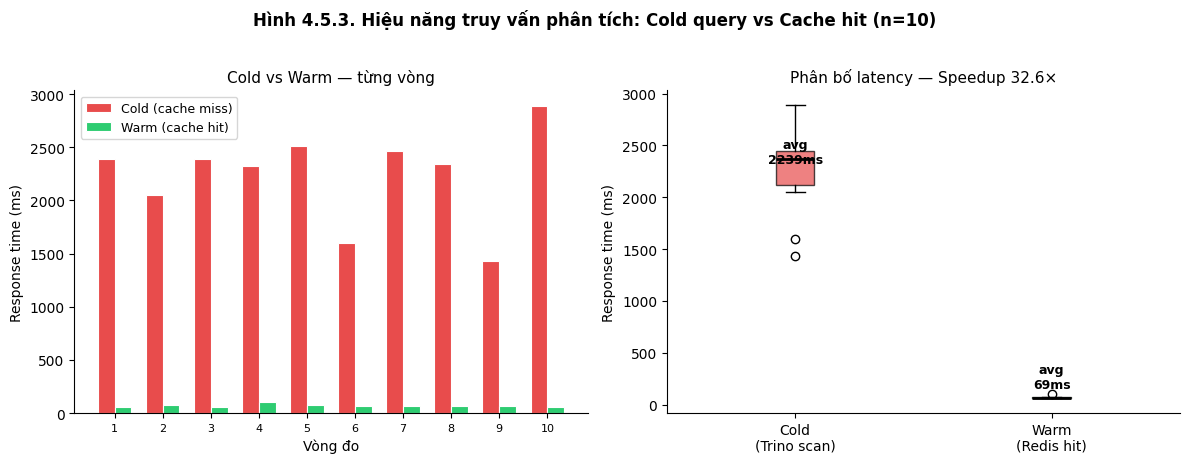

In [7]:
# ── Vẽ Hình 4.5.3 — So sánh Cold vs Warm latency ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

rounds = list(range(1, len(cold_ms_list) + 1))
cold_color = "#E84C4C"
warm_color = "#2ECC71"

# --- Bar chart so sánh từng vòng ---
ax1 = axes[0]
x = np.arange(len(rounds))
w = 0.35
ax1.bar(x - w/2, cold_ms_list, width=w, color=cold_color, label="Cold (cache miss)",
        edgecolor="white", linewidth=0.8)
ax1.bar(x + w/2, warm_ms_list, width=w, color=warm_color, label="Warm (cache hit)",
        edgecolor="white", linewidth=0.8)
ax1.set_xticks(list(x))
ax1.set_xticklabels([str(r) for r in rounds], fontsize=8)
ax1.set_xlabel("Vòng đo")
ax1.set_ylabel("Response time (ms)")
ax1.set_title("Cold vs Warm — từng vòng", fontsize=11)
ax1.legend(fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

# --- Box plot phân bố ---
ax2 = axes[1]
bp = ax2.boxplot(
    [cold_ms_list, warm_ms_list],
    tick_labels=["Cold\n(Trino scan)", "Warm\n(Redis hit)"],   # matplotlib ≥3.9
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
)
bp["boxes"][0].set_facecolor(cold_color)
bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor(warm_color)
bp["boxes"][1].set_alpha(0.7)
for i, (arr, x_pos) in enumerate([(cold_ms_list, 1), (warm_ms_list, 2)]):
    avg = statistics.mean(arr)
    ax2.text(x_pos, avg + max(cold_ms_list) * 0.03,
             f"avg\n{avg:.0f}ms", ha="center", fontsize=9, fontweight="bold")
ax2.set_ylabel("Response time (ms)")
ax2.set_title(f"Phân bố latency — Speedup {speedup_avg}×", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Hình 4.5.3. Hiệu năng truy vấn phân tích: Cold query vs Cache hit (n={len(cold_ms_list)})",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()

out_path = f"{FIG_DIR}/hinh_4_5_3_cold_vs_cache.png"
fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
print(f"Đã lưu: {out_path}")
plt.show()

---
## 4.5.4 — Độ trễ truyền tải hình ảnh (Image Transmission Latency)

**Đường đo**: Redis lưu JPEG snapshot → FastAPI đọc và phục vụ qua `GET /media/live/{camera_id}/snapshot.jpg` → client nhận ảnh.

**Mục đích**: Đo thời gian từ khi client gửi request đến khi nhận đủ file ảnh JPEG (bao gồm server read từ Redis + HTTP transfer). Phản ánh trải nghiệm người dùng cuối khi xem live snapshot trên dashboard.

In [8]:
# ── Thu thập mẫu image transmission latency ───────────────────────────────────
# Endpoint: GET /media/live/{camera_id}/snapshot.jpg
# Đo: tổng response time (ms) + kích thước file ảnh (KB)
# Khác 4.5.2: dùng urllib trực tiếp (binary response), không JSON

import urllib.request
import time
import statistics
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

SNAPSHOT_TMPL = API_BASE + "/media/live/{cam_id}/snapshot.jpg"
N_SAMPLES_454 = 30
INTERVAL_454  = 0.5   # giây giữa các lần đo

records_454 = []

print(f"Bắt đầu thu thập {N_SAMPLES_454} mẫu × {len(CAMERA_IDS)} camera (snapshot)...\n")
for cam in CAMERA_IDS:
    url = SNAPSHOT_TMPL.format(cam_id=cam)
    cam_times = []
    for i in range(N_SAMPLES_454):
        t0 = time.perf_counter()
        try:
            with urllib.request.urlopen(url, timeout=15) as resp:
                body = resp.read()
                elapsed_ms = (time.perf_counter() - t0) * 1000
                size_bytes = len(body)
                status = resp.status
        except Exception as exc:
            elapsed_ms = None
            size_bytes = None
            status = -1
            print(f"  [{cam}] sample {i+1} error: {exc}")

        if elapsed_ms is not None:
            records_454.append({
                "camera_id":   cam,
                "sample":      i + 1,
                "response_ms": round(elapsed_ms, 1),
                "size_bytes":  size_bytes,
                "status":      status,
            })
            cam_times.append(elapsed_ms)

        if i < N_SAMPLES_454 - 1:
            time.sleep(INTERVAL_454)

    if cam_times:
        print(f"[{cam}] {len(cam_times)} mẫu OK — avg={statistics.mean(cam_times):.0f}ms  "
              f"min={min(cam_times):.0f}ms  max={max(cam_times):.0f}ms")

df_454 = pd.DataFrame(records_454)
df_454["size_kb"] = df_454["size_bytes"] / 1024

print(f"\nTổng mẫu hợp lệ: {len(df_454)}  |  Camera: {df_454['camera_id'].nunique()}")
df_454.head(6)

Bắt đầu thu thập 30 mẫu × 2 camera (snapshot)...



[cam_01] 30 mẫu OK — avg=294ms  min=197ms  max=1153ms


[cam_02] 30 mẫu OK — avg=305ms  min=228ms  max=505ms

Tổng mẫu hợp lệ: 60  |  Camera: 2


,camera_id,sample,response_ms,size_bytes,status,size_kb
0,cam_01,1,853.9,273350,200,266.943359
1,cam_01,2,217.5,274679,200,268.241211
2,cam_01,3,266.8,274919,200,268.475586
3,cam_01,4,259.6,274919,200,268.475586
4,cam_01,5,293.0,273918,200,267.498047
5,cam_01,6,265.5,273725,200,267.309570


In [9]:
# ── Thống kê và in Bảng 4.5.4 ─────────────────────────────────────────────────
if df_454.empty:
    print("⚠️  Không có mẫu hợp lệ — kiểm tra lại kết nối API.")
else:
    rsp  = df_454["response_ms"].astype(float).tolist()
    sz   = df_454["size_kb"].astype(float).tolist()

    rows_454 = []
    for label, arr, unit in [
        ("Response time (ms)", rsp, "ms"),
        ("Image size (KB)",    sz,  "KB"),
    ]:
        rows_454.append({
            "Chỉ số":  label,
            "Min":     round(min(arr), 1),
            "Avg":     round(statistics.mean(arr), 1),
            "P50":     round(float(np.percentile(arr, 50)), 1),
            "P95":     round(float(np.percentile(arr, 95)), 1),
            "P99":     round(float(np.percentile(arr, 99)), 1),
            "Max":     round(max(arr), 1),
        })

    df_stat_454 = pd.DataFrame(rows_454)
    avg_rsp = round(statistics.mean(rsp), 1)
    p95_rsp = round(float(np.percentile(rsp, 95)), 1)
    avg_sz  = round(statistics.mean(sz), 1)

    print(f"Số mẫu: {len(rsp)}  |  n_cameras: {df_454['camera_id'].nunique()}")
    print(f"Avg response: {avg_rsp} ms  |  P95: {p95_rsp} ms  |  Avg size: {avg_sz:.1f} KB\n")
    display(df_stat_454.style.hide(axis="index"))
    print("\n→ Copy bảng trên vào Bảng 4.5.4 trong báo cáo.")

Số mẫu: 60  |  n_cameras: 2
Avg response: 299.9 ms  |  P95: 498.9 ms  |  Avg size: 346.4 KB



Chỉ số,Min,Avg,P50,P95,P99,Max
Response time (ms),196.700000,299.900000,264.500000,498.900000,976.700000,1153.400000
Image size (KB),266.300000,346.400000,341.200000,431.000000,433.900000,435.400000



→ Copy bảng trên vào Bảng 4.5.4 trong báo cáo.


Đã lưu: ./hinh_4_5_4_image_latency.png


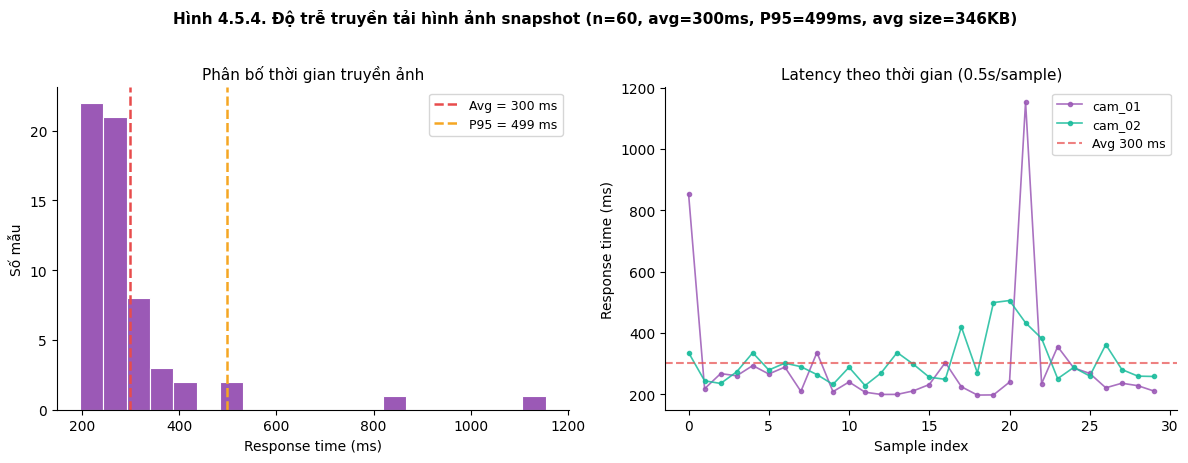

In [10]:
# ── Vẽ Hình 4.5.4 — Phân bố Image Transmission Latency ───────────────────────
if df_454.empty:
    print("⚠️  Không có dữ liệu để vẽ.")
else:
    rsp = df_454["response_ms"].astype(float).tolist()
    sz  = df_454["size_kb"].astype(float).tolist()
    avg_rsp = statistics.mean(rsp)
    p95_rsp = float(np.percentile(rsp, 95))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # --- Histogram phân bố response time ---
    ax1 = axes[0]
    ax1.hist(rsp, bins=20, color="#9B59B6", edgecolor="white", linewidth=0.8)
    ax1.axvline(avg_rsp, color="#E84C4C", linestyle="--", linewidth=1.8,
                label=f"Avg = {avg_rsp:.0f} ms")
    ax1.axvline(p95_rsp, color="#F5A623", linestyle="--", linewidth=1.8,
                label=f"P95 = {p95_rsp:.0f} ms")
    ax1.set_xlabel("Response time (ms)")
    ax1.set_ylabel("Số mẫu")
    ax1.set_title("Phân bố thời gian truyền ảnh", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.spines[["top", "right"]].set_visible(False)

    # --- Time series theo camera ---
    ax2 = axes[1]
    colors_cam = {"cam_01": "#9B59B6", "cam_02": "#1ABC9C"}
    for cam in CAMERA_IDS:
        sub = df_454[df_454["camera_id"] == cam]["response_ms"].astype(float).reset_index(drop=True)
        if len(sub):
            ax2.plot(sub.index, sub.values, marker="o", markersize=3,
                     linewidth=1.2, label=cam, alpha=0.85,
                     color=colors_cam.get(cam, "#888"))
    ax2.axhline(avg_rsp, color="#E84C4C", linestyle="--", linewidth=1.5,
                label=f"Avg {avg_rsp:.0f} ms", alpha=0.7)
    ax2.set_xlabel("Sample index")
    ax2.set_ylabel("Response time (ms)")
    ax2.set_title(f"Latency theo thời gian ({INTERVAL_454}s/sample)", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.spines[["top", "right"]].set_visible(False)

    avg_sz = statistics.mean(sz)
    fig.suptitle(
        f"Hình 4.5.4. Độ trễ truyền tải hình ảnh snapshot "
        f"(n={len(rsp)}, avg={avg_rsp:.0f}ms, P95={p95_rsp:.0f}ms, avg size={avg_sz:.0f}KB)",
        fontsize=11, fontweight="bold", y=1.02
    )
    plt.tight_layout()

    out_path = f"{FIG_DIR}/hinh_4_5_4_image_latency.png"
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    print(f"Đã lưu: {out_path}")
    plt.show()

---
## Checklist sau khi chạy xong

| Mục | File / Việc cần làm |
|-----|---------------------|
| Bảng 4.5.2 | Copy stats E2E latency → Word |
| Hình 4.5.2  | Chèn `hinh_4_5_2_e2e_latency.png` → Word |
| Bảng 4.5.3 | Copy Cold/Warm stats → Word |
| Hình 4.5.3  | Chèn `hinh_4_5_3_cold_vs_cache.png` → Word |
| Bảng 4.5.4 | Copy Image Transmission stats → Word |
| Hình 4.5.4  | Chèn `hinh_4_5_4_image_latency.png` → Word |
| Speedup     | Ghi số liệu `speedup_avg` và `CACHE_TTL_SEC` vào phần phân tích |
| Số hiệu hình | Điều chỉnh lại số Hình 4.x theo thứ tự thực tế trong Word |